In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('input/WaterQualityPrediction.csv')

print(df['Source'].unique())

df = df[df['Source'] == 'River']
df = df[df['Month'].notna() & df['Day'].notna()]

df.info()

[nan 'Lake' 'River' 'Ground' 'Spring' 'Stream' 'Aquifer' 'Reservoir'
 'Well']
<class 'pandas.core.frame.DataFrame'>
Index: 124763 entries, 2 to 1048561
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Index                   124763 non-null  int64  
 1   pH                      122313 non-null  float64
 2   Iron                    123945 non-null  float64
 3   Nitrate                 122584 non-null  float64
 4   Chloride                121060 non-null  float64
 5   Lead                    124221 non-null  float64
 6   Zinc                    121425 non-null  float64
 7   Color                   124635 non-null  object 
 8   Turbidity               123690 non-null  float64
 9   Fluoride                120831 non-null  float64
 10  Copper                  120665 non-null  float64
 11  Odor                    121179 non-null  float64
 12  Sulfate                 120721 non-null  float64
 13  

In [3]:

def month_name_to_number(month_name):

    month_map = {
        "january": 1, "february": 2, "march": 3, "april": 4,
        "may": 5, "june": 6, "july": 7, "august": 8,
        "september": 9, "october": 10, "november": 11, "december": 12
    }
    
    # Normalize the input to lowercase and return the mapped value
    return month_map.get(month_name.strip().lower())

In [4]:
df['Year'] = 2022
df['Month'] = df['Month'].apply(month_name_to_number)
df['Hour'] = df['Time of Day']
df['Minute'] = np.random.choice(
    list(range(0, 59)), size=(df.shape[0],)
)
df['Second'] = np.random.choice(
    list(range(0, 59)), size=(df.shape[0],)
)

df['SensorID'] = np.random.choice(
    list(range(0, 6)), size=(df.shape[0],)
)
# Combine columns into a datetime column
df["DateTime"] = pd.to_datetime(
    df[["Year", "Month", "Day", "Hour", 'Minute','Second']]
)

df["WeekNumber"] = df["DateTime"].dt.isocalendar().week
df["DayNumber"] = df["DateTime"].dt.dayofyear


In [5]:
# get the number of observations per day
df.groupby('DayNumber').agg({'DateTime': 'count'}).reset_index()

,DayNumber,DateTime
0,1.0,378
1,2.0,324
2,3.0,348
3,4.0,333
4,5.0,360
...,...,...
360,361.0,352
361,362.0,344
362,363.0,340
363,364.0,342


<Axes: xlabel='DateTime', ylabel='Turbidity'>

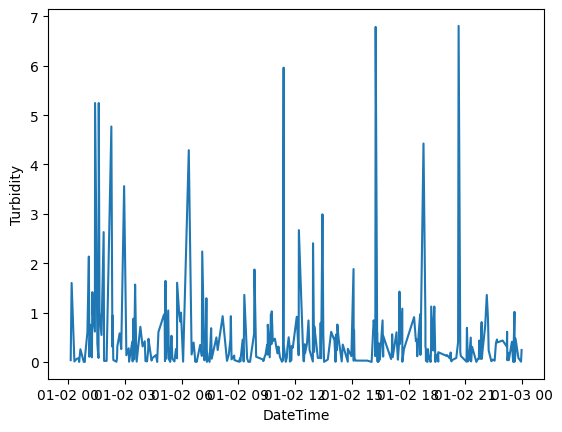

In [6]:
sns.lineplot(
    df[df['DayNumber']==2], 
    x='DateTime', y='Turbidity'
)

In [7]:
df.columns

Index(['Index', 'pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color',
       'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity',
       'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Source',
       'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day',
       'Target', 'Year', 'Hour', 'Minute', 'Second', 'SensorID', 'DateTime',
       'WeekNumber', 'DayNumber'],
      dtype='object')

In [10]:
columns = ['SensorID', 'DateTime', 'Lead', 'Turbidity', 'pH']
df = df.loc[:, columns]
df = df.sort_values('DateTime')

df.to_csv('./input/sorted_streaming_data.csv', index=None)